# 05 — Churn Prediction Model

**Goal:** predict which customers will place **no order in the 60 days after the observation date**
(`Churn60 = 1`), using `customer_analytics.csv`.

**How the data was set up (so the model can't cheat):**

```
orders up to 2024-11-01  ->  features (TotalOrders, RecencyDays, ratings, ...)
                                  |
                          observation date: 2024-11-01
                                  |
next 60 days             ->  Churn60 = 1 if the customer did NOT order
```

Every feature only uses information from *before* the observation date, so there is no
leakage from the future. The code lives in `src/model_churn.py` — this notebook just calls it
and shows the results.

## Step 1 — Load the data

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from model_churn import (
    load_customer_analytics, prepare_features, split_data,
    train_baseline_models, compare_models, tune_best_models, score_model,
    get_feature_importance, build_predictions, save_model,
)

df = load_customer_analytics("../data/analytical/customer_analytics.csv")
print("Customers:", len(df))
print("Churn rate:", round(df["Churn60"].mean() * 100, 1), "%")

Customers: 9254
Churn rate: 87.8 %


## Step 2 — Class imbalance

About 88% of customers churn, so the classes are very unbalanced. Two consequences:

1. Plain **accuracy is misleading** — a "model" that says *everyone churns* is already 88% accurate.
2. The models need **class weights** so they don't just ignore the small "did not churn" group.
   (`class_weight="balanced"` for Logistic Regression / Decision Tree / Random Forest,
   balanced sample weights for Gradient Boosting — see `model_churn.py`.)

Below is that "everyone churns" baseline. **Any real model has to beat it.**

In [2]:
y_all = df["Churn60"]
print(y_all.value_counts().rename({1: "Churned", 0: "Did not churn"}))

# Naive baseline: predict "churn" for everybody
baseline = {
    "Accuracy": accuracy_score(y_all, [1] * len(y_all)),
    "Precision": precision_score(y_all, [1] * len(y_all)),
    "Recall": 1.0,
    "F1": f1_score(y_all, [1] * len(y_all)),
    "ROC_AUC": 0.5,   # a constant guess has no ranking ability by definition
}
baseline_row = pd.DataFrame({"Everyone churns (baseline)": baseline}).T.round(3)
baseline_row

Churn60
Churned          8123
Did not churn    1131
Name: count, dtype: int64


,Accuracy,Precision,Recall,F1,ROC_AUC
Everyone churns (baseline),0.878,0.878,1.0,0.935,0.5


## Step 3 — Prepare features and split

In [3]:
X, y = prepare_features(df)
X_train, X_test, y_train, y_test = split_data(X, y)   # 80/20, stratified

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: (7403, 18) | Test: (1851, 18)
Churn rate  train: 0.878  test: 0.878


## Step 4 — Train the 4 baseline models

Logistic Regression, Decision Tree, Random Forest, Gradient Boosting — each wrapped in the
same preprocessing (median fill + scaling for numbers, "Unknown" + one-hot for categories).

In [4]:
results, fitted = train_baseline_models(X_train, y_train, X_test, y_test)
baseline_table = compare_models(results)
baseline_table

,Accuracy,Precision,Recall,F1,ROC_AUC
Decision Tree,0.619,0.878,0.658,0.752,0.507
Logistic Regression,0.499,0.874,0.502,0.637,0.501
Random Forest,0.820,0.877,0.925,0.900,0.494
Gradient Boosting,0.579,0.875,0.607,0.717,0.487


### Reading this table

- **ROC-AUC is the number to trust here.** 0.5 = random guessing, 1.0 = perfect.
- All four models sit right around **0.5**.
- Random Forest's high F1 (~0.90) looks good but is not — it just labels most customers as churn,
  which is what the baseline does too, and the baseline's F1 is actually higher.

Before tuning anything, let's check whether the data contains any signal at all.

## Step 5 — Is there any signal to find?

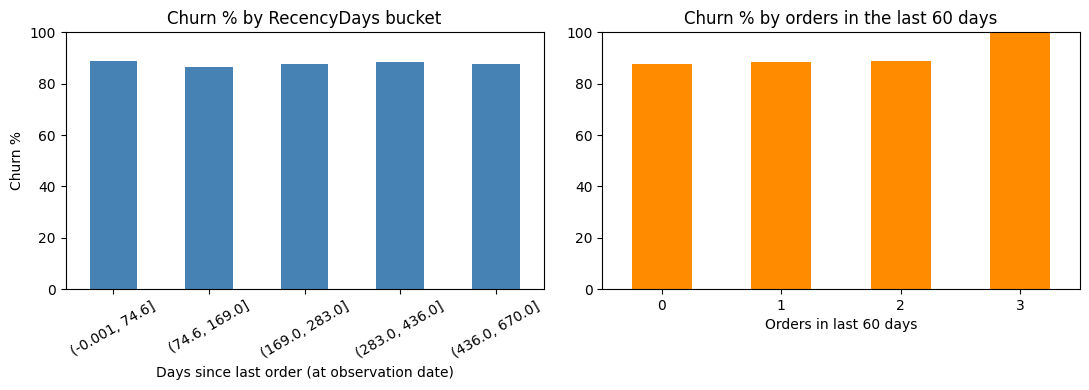

In [5]:
# If recent activity really predicted retention, churn would be clearly LOWER for recent customers.
buckets = pd.qcut(df["RecencyDays"], 5, duplicates="drop")
by_recency = df.groupby(buckets, observed=True)["Churn60"].mean().mul(100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

by_recency.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Churn % by RecencyDays bucket")
ax[0].set_xlabel("Days since last order (at observation date)")
ax[0].set_ylabel("Churn %")
ax[0].set_ylim(0, 100)
ax[0].tick_params(axis="x", rotation=30)

by_orders = df.groupby("OrdersLast60Days")["Churn60"].mean().mul(100).round(1)
by_orders.plot(kind="bar", ax=ax[1], color="darkorange")
ax[1].set_title("Churn % by orders in the last 60 days")
ax[1].set_xlabel("Orders in last 60 days")
ax[1].set_ylim(0, 100)
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../images/ml/churn_signal_check.png", dpi=120, bbox_inches="tight")
plt.show()

**What this shows:** churn is ~88% in *every* bucket. Customers who ordered last week are just as
likely to "churn" as customers who haven't ordered in a year. There is essentially no
behavioural pattern in this data for a model to learn — the ROC-AUC ≈ 0.5 result is a fact about
the dataset, not a bug in the code. Tuning below is still done (the plan requires it), but
we shouldn't expect it to change the conclusion.

## Step 6 — Tune the top 2 models

In [6]:
top_two = list(baseline_table.index[:2])
print("Tuning:", top_two)

tuned = tune_best_models(X_train, y_train, top_two)

tuned_results = {name: score_model(pipe, X_test, y_test) for name, pipe in tuned.items()}
tuned_table = compare_models(tuned_results)
tuned_table

Tuning: ['Decision Tree', 'Logistic Regression']


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.500,0.873,0.503,0.639,0.501
Decision Tree,0.301,0.877,0.237,0.373,0.494


In [7]:
# Everything side by side: baseline, 4 untuned models, tuned models
full_table = pd.concat([
    baseline_row.assign(Stage="Naive baseline"),
    baseline_table.assign(Stage="Default"),
    tuned_table.assign(Stage="Tuned"),
])
full_table = full_table[["Stage", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
full_table

,Stage,Accuracy,Precision,Recall,F1,ROC_AUC
Everyone churns (baseline),Naive baseline,0.878,0.878,1.000,0.935,0.500
Decision Tree,Default,0.619,0.878,0.658,0.752,0.507
Logistic Regression,Default,0.499,0.874,0.502,0.637,0.501
Random Forest,Default,0.820,0.877,0.925,0.900,0.494
Gradient Boosting,Default,0.579,0.875,0.607,0.717,0.487
Logistic Regression,Tuned,0.500,0.873,0.503,0.639,0.501
Decision Tree,Tuned,0.301,0.877,0.237,0.373,0.494


## Step 7 — Pick the best model

Chosen by **ROC-AUC** (the fairest metric under class imbalance). Because every model is near 0.5,
the "best" one only wins by a tiny margin that is within normal random variation — so this is a
formality, not evidence of a strong model.

In [8]:
best_name = tuned_table["ROC_AUC"].idxmax()
best_model = tuned[best_name]
print("Best model:", best_name)
print(tuned_table.loc[best_name].to_string())

Best model: Logistic Regression
Accuracy     0.500
Precision    0.873
Recall       0.503
F1           0.639
ROC_AUC      0.501


## Step 8 — Confusion matrix and ROC curve

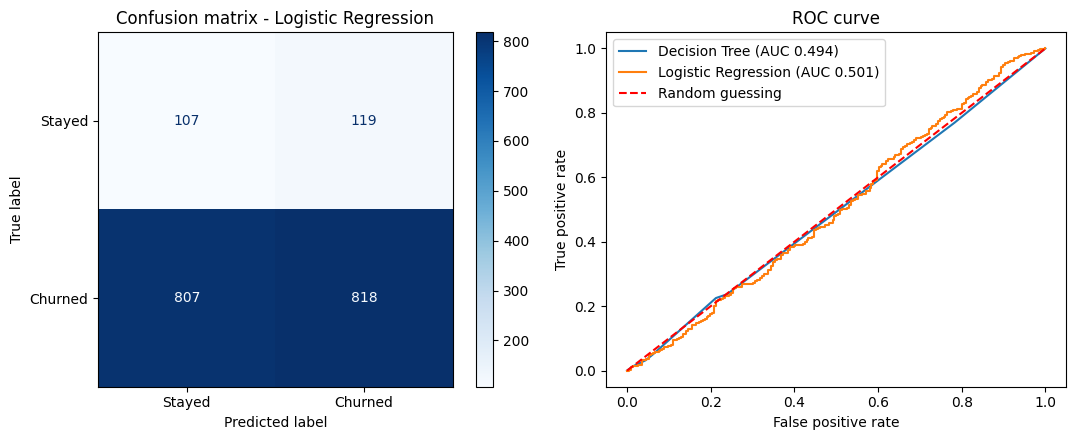

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax[0]
)
ax[0].set_title(f"Confusion matrix - {best_name}")

# ROC curves for the tuned models (+ the diagonal = random guessing)
for name, pipe in tuned.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, probs):.3f})")
ax[1].plot([0, 1], [0, 1], "r--", label="Random guessing")
ax[1].set_xlabel("False positive rate")
ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve")
ax[1].legend()

plt.tight_layout()
plt.savefig("../images/ml/churn_confusion_roc.png", dpi=120, bbox_inches="tight")
plt.show()

The ROC curve hugging the diagonal is the same story as the table: the model can't rank
customers by churn risk any better than a coin flip.

## Step 9 — Feature importance

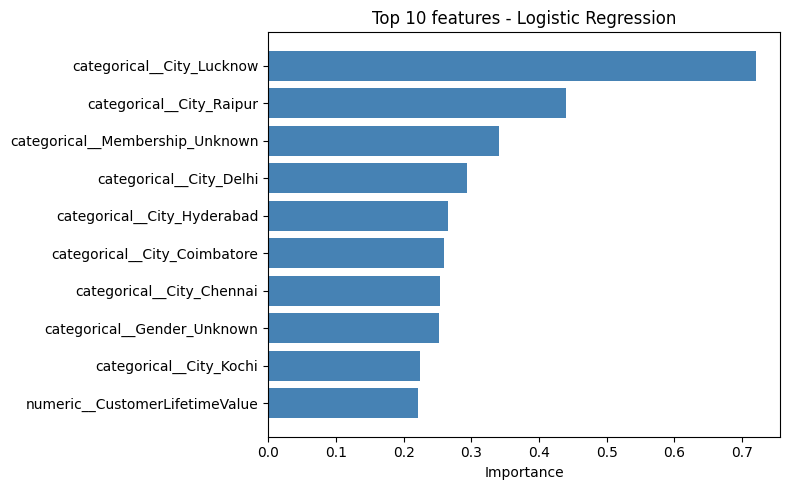

,Feature,Importance
0,categorical__City_Lucknow,0.720130
1,categorical__City_Raipur,0.440478
2,categorical__Membership_Unknown,0.341097
3,categorical__City_Delhi,0.294068
4,categorical__City_Hyderabad,0.265806
5,categorical__City_Coimbatore,0.259729
6,categorical__City_Chennai,0.253095
7,categorical__Gender_Unknown,0.252216
8,categorical__City_Kochi,0.224600
9,numeric__CustomerLifetimeValue,0.221602


In [10]:
importance = get_feature_importance(best_model, best_name)
top10 = importance.head(10).iloc[::-1]   # reversed so the biggest bar is on top

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance"], color="steelblue")
plt.title(f"Top 10 features - {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/ml/churn_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

importance.head(10)

Importance only tells us what the model *used*, not that those features truly drive churn —
with no real signal, the model ends up leaning on small quirks in the data (a handful of city
and membership groups). Read this chart as "what the model looked at", not "why customers leave".

## Step 10 — Churn probabilities and risk segments

In [11]:
predictions = build_predictions(best_model, df, X_train.index)

print(predictions["RiskSegment"].value_counts())
print()
predictions.head()

RiskSegment
Medium    8920
High       322
Low         12
Name: count, dtype: int64



,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,RiskSegment,Split
0,1,1,1,0.5790,Medium,Train
1,2,1,1,0.5669,Medium,Test
2,3,1,1,0.5368,Medium,Test
3,6,1,1,0.5342,Medium,Train
4,7,1,1,0.5555,Medium,Train


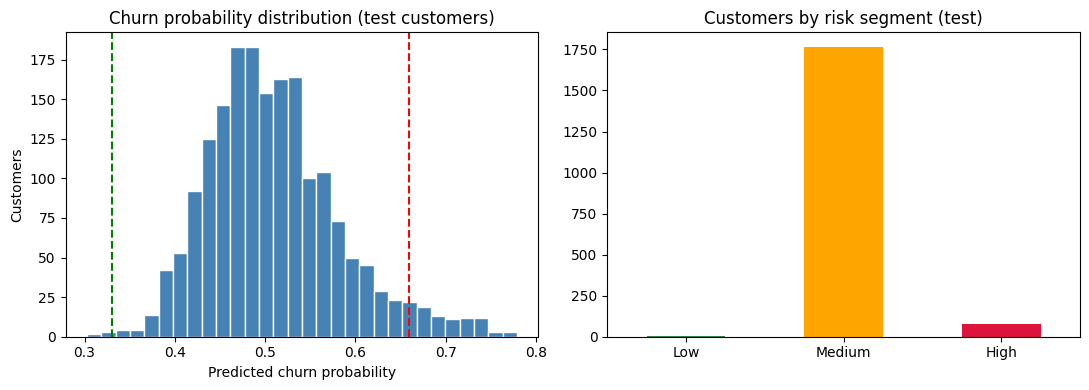

In [12]:
test_only = predictions[predictions["Split"] == "Test"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(test_only["ChurnProbability"], bins=30, color="steelblue", edgecolor="white")
ax[0].axvline(0.33, color="green", linestyle="--")
ax[0].axvline(0.66, color="red", linestyle="--")
ax[0].set_title("Churn probability distribution (test customers)")
ax[0].set_xlabel("Predicted churn probability")
ax[0].set_ylabel("Customers")

order = ["Low", "Medium", "High"]
test_only["RiskSegment"].value_counts().reindex(order).fillna(0).plot(
    kind="bar", ax=ax[1], color=["seagreen", "orange", "crimson"]
)
ax[1].set_title("Customers by risk segment (test)")
ax[1].set_xlabel("")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../images/ml/churn_probability_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## Step 11 — Save everything

In [13]:
save_model(best_model, "../models/churn_best_model.pkl")
predictions.to_csv("../outputs/churn_predictions.csv", index=False)
full_table.to_csv("../outputs/model_comparison_churn.csv")
importance.to_csv("../outputs/feature_importance_churn.csv", index=False)

print("Saved:")
print("  models/churn_best_model.pkl")
print("  outputs/churn_predictions.csv          (all customers; 'Split' column marks Train/Test)")
print("  outputs/model_comparison_churn.csv")
print("  outputs/feature_importance_churn.csv")

Saved:
  models/churn_best_model.pkl
  outputs/churn_predictions.csv          (all customers; 'Split' column marks Train/Test)
  outputs/model_comparison_churn.csv
  outputs/feature_importance_churn.csv


## Conclusions

1. **Method is sound:** features are built only from pre-observation-date data, the target looks
   60 days ahead, the split is stratified, and imbalance is handled with class weights.
2. **The models do not beat guessing** (ROC-AUC ≈ 0.5). The naive "everyone churns" rule has
   higher accuracy and F1 than any of them.
3. **Reason:** churn is ~88% regardless of recency, order count, membership or coupon use. In this
   dataset, past ordering behaviour simply doesn't predict who orders in the next 60 days.
4. **For Power BI:** `churn_predictions.csv` is ready to use for the risk-segment visuals, but the
   probabilities cluster in the middle, so the segments should be presented as a *demonstration
   of the pipeline*, not as a reliable targeting list.

**Limitations / next steps:** customers average only ~1.9 orders over two years, which leaves very
little history per person; a real business would test extra signals (app activity, complaints,
delivery issues) before relying on a churn model.